# Proyek Machine Learning - Clustering
**Nama:** Muhammad Dhiyaul Atha

## Penting
Notebook ini berisi proses clustering pada dataset Bank Transaction untuk mendeteksi pola transaksi

## 1. Import Library
Pada tahap ini, kita mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

## INFORMASI DATASET
## 2. Memuat Dataset

**Metode:** Menggunakan `pd.read_csv()` untuk memuat dataset.
**Alasan:** Format CSV mudah dibaca dan kompatibel dengan pandas.

In [30]:
df = pd.read_csv('bank_transactions_data_edited.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance           2510 non-n

In [32]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


### Penilaian
#### Matriks Korelasi & Histogram
**Metode:** Matriks korelasi menggunakan `heatmap` dan histogram untuk semua kolom.
**Alasan:** Untuk melihat hubungan antar fitur numerik dan distribusi data.

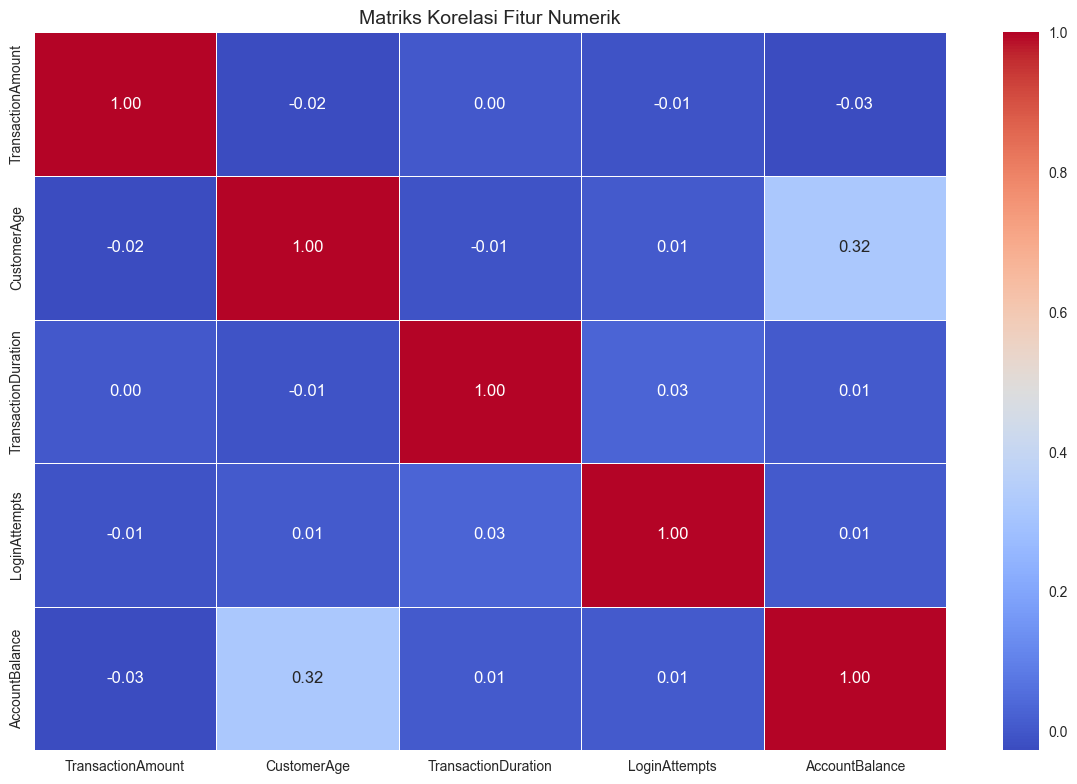

In [33]:
# Matriks Korelasi
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

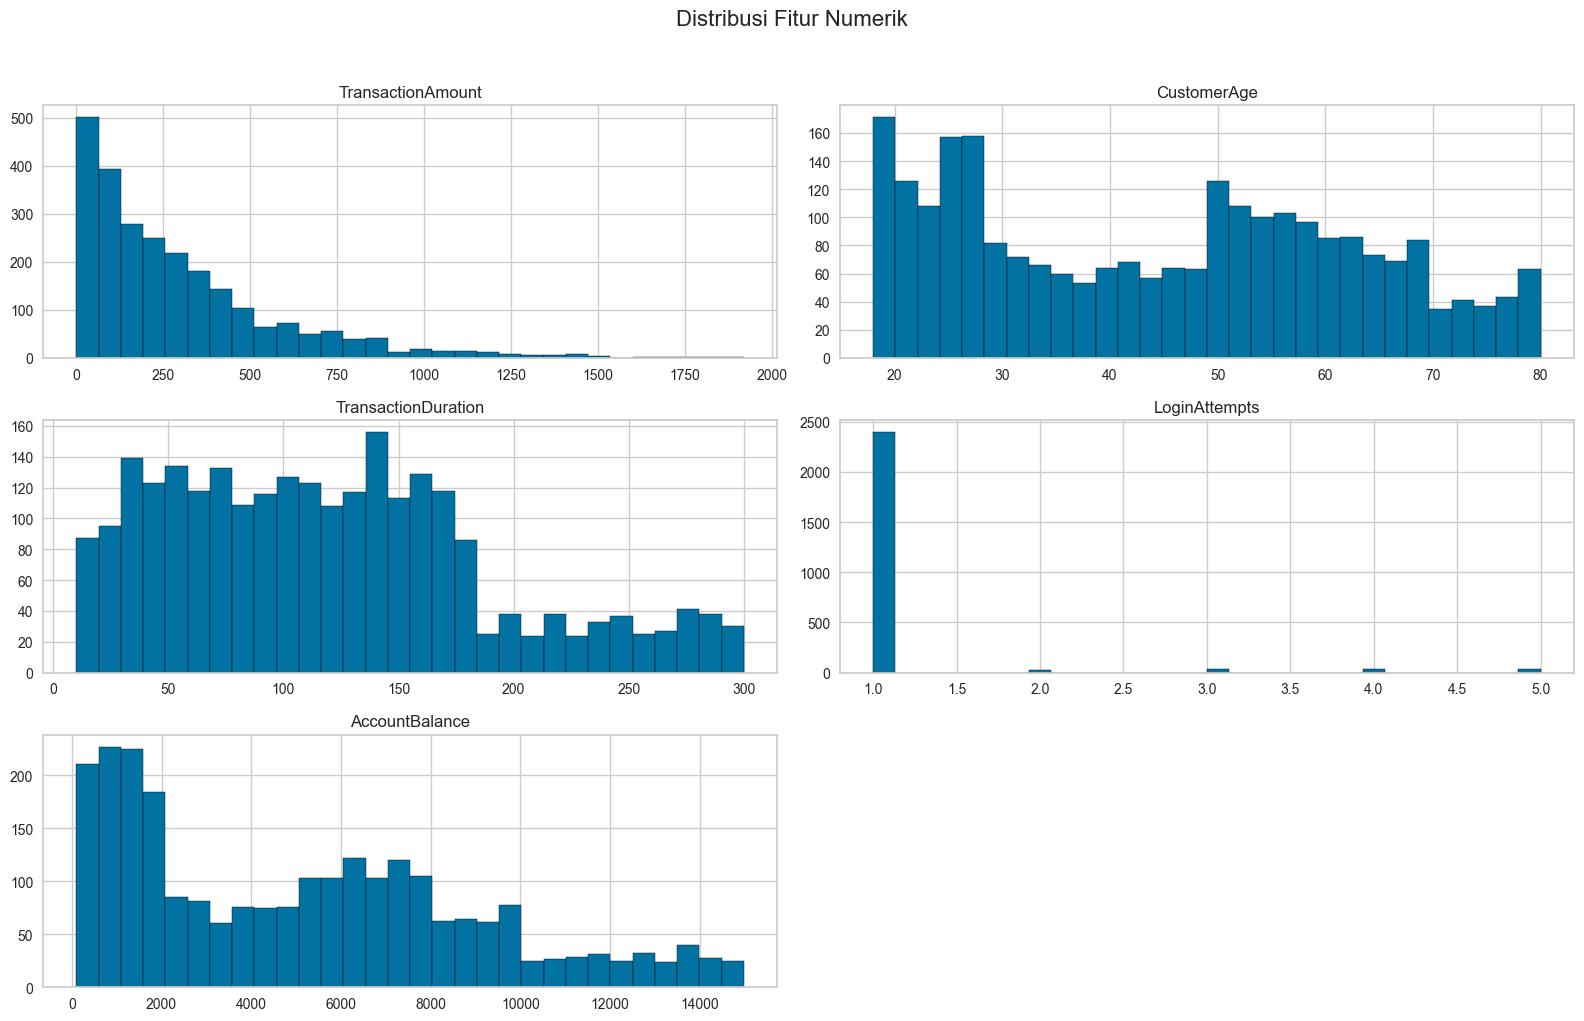

In [34]:
# Histogram semua kolom numerik
df[numeric_cols].hist(bins=30, figsize=(16, 10), edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

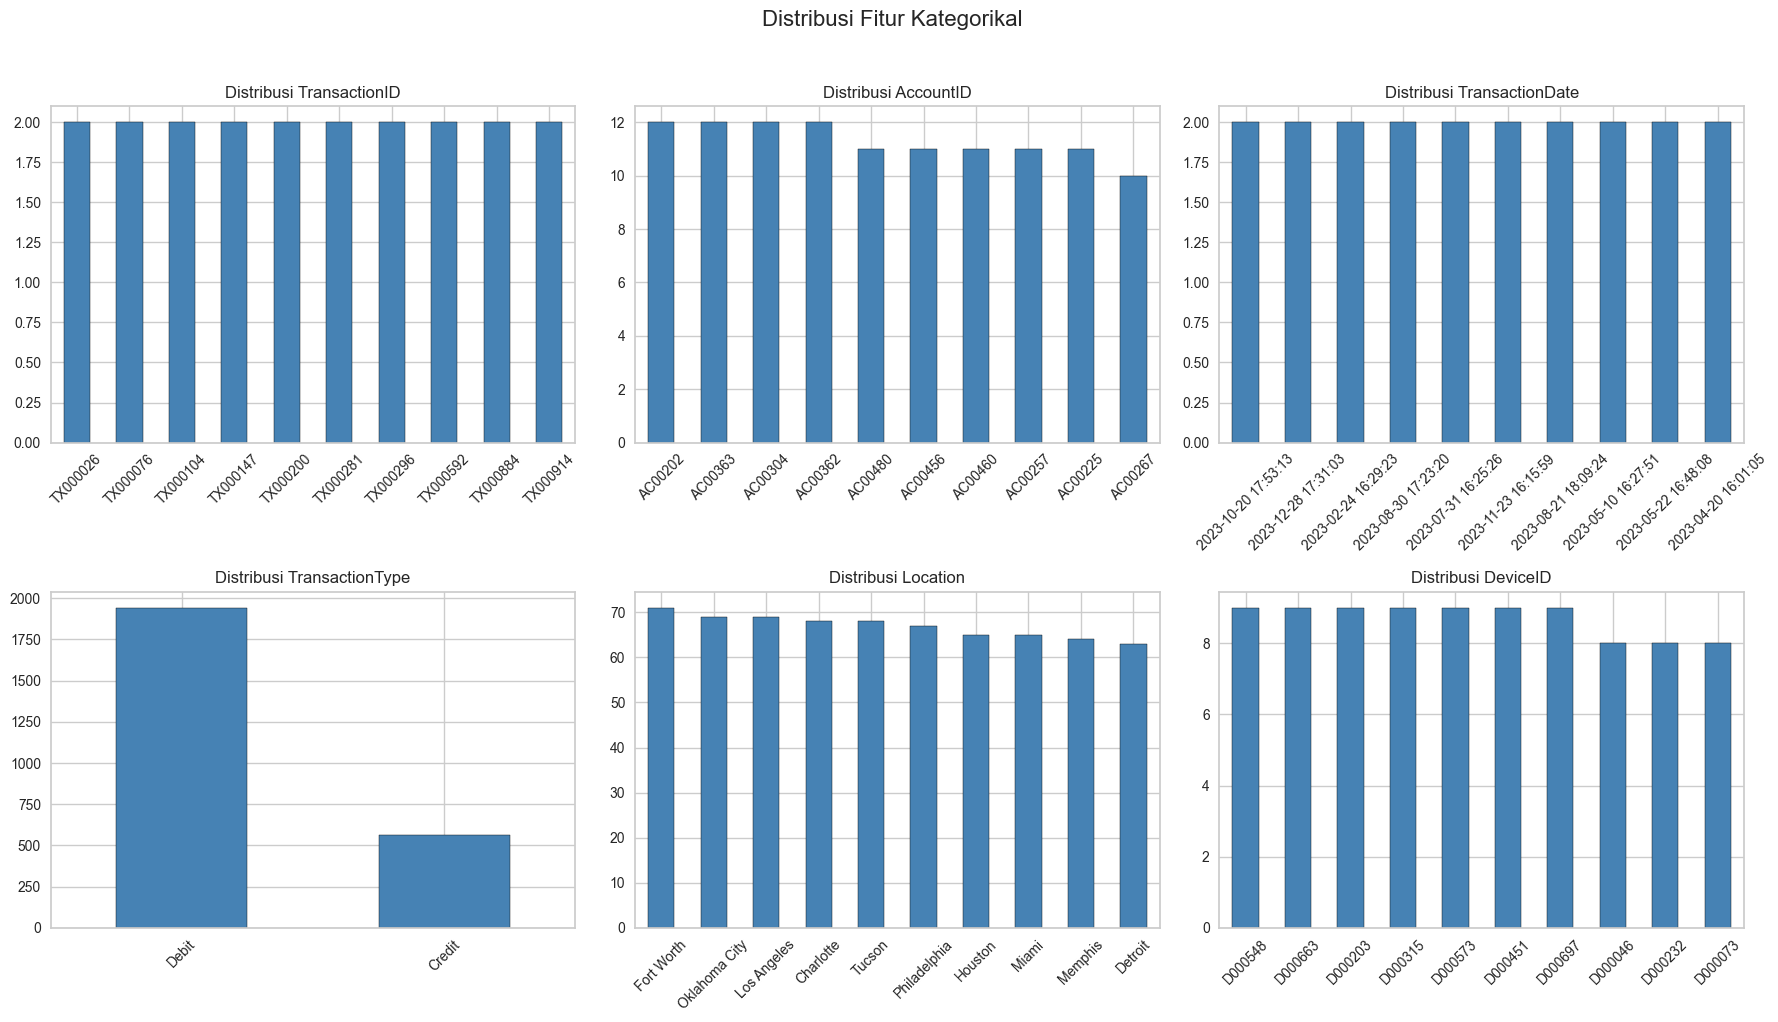

In [35]:
# Histogram kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3. Pembersihan dan Pra Pemrosesan Data

**Metode:** Mengecek missing values dan duplikat, lalu membersihkan data.
**Alasan:** Data yang bersih menghasilkan model yang lebih akurat.

In [36]:
# Cek missing values dan duplikat
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal Missing: {df.isnull().sum().sum()}")
print(f"\nData Duplikat: {df.duplicated().sum()}")

Missing Values:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

Total Missing: 403

Data Duplikat: 21


In [37]:
# Hapus missing values dan duplikat
df = df.dropna()
df = df.drop_duplicates()
print(f"Shape setelah cleaning: {df.shape}")

Shape setelah cleaning: (2135, 16)


In [38]:
# Drop kolom ID, Address, dan Date
columns_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 
                   'IP Address', 'MerchantID', 'TransactionDate',
                   'PreviousTransactionDate']

df = df.drop(columns=columns_to_drop)
print(f"Kolom tersisa: {list(df.columns)}")
print(f"Shape: {df.shape}")

Kolom tersisa: ['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
Shape: (2135, 9)


In [39]:
# Label Encoding untuk fitur kategorikal
label_encoders = {}
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal: {categorical_columns}\n")

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"'{col}': {list(le.classes_)}")

df.head()

Kolom kategorikal: ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

'TransactionType': ['Credit', 'Debit']
'Location': ['Albuquerque', 'Atlanta', 'Austin', 'Baltimore', 'Boston', 'Charlotte', 'Chicago', 'Colorado Springs', 'Columbus', 'Dallas', 'Denver', 'Detroit', 'El Paso', 'Fort Worth', 'Fresno', 'Houston', 'Indianapolis', 'Jacksonville', 'Kansas City', 'Las Vegas', 'Los Angeles', 'Louisville', 'Memphis', 'Mesa', 'Miami', 'Milwaukee', 'Nashville', 'New York', 'Oklahoma City', 'Omaha', 'Philadelphia', 'Phoenix', 'Portland', 'Raleigh', 'Sacramento', 'San Antonio', 'San Diego', 'San Francisco', 'San Jose', 'Seattle', 'Tucson', 'Virginia Beach', 'Washington']
'Channel': ['ATM', 'Branch', 'Online']
'CustomerOccupation': ['Doctor', 'Engineer', 'Retired', 'Student']


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


### Penilaian
#### Handling Outlier & Feature Scaling

**Metode:** Outlier di-drop menggunakan metode IQR, lalu scaling menggunakan `StandardScaler()`.
**Alasan:** Outlier bisa mempengaruhi hasil clustering, dan scaling memastikan semua fitur punya skala yang sama.

In [40]:
# Handling Outlier menggunakan metode IQR (drop)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Data sebelum handling outlier: {df.shape}")
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Data setelah handling outlier: {df.shape}")

Data sebelum handling outlier: (2135, 9)
Data setelah handling outlier: (1501, 9)


In [41]:
# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.107930,0.0,1.200869,-1.088615,1.444427,-1.316889,-0.537894,0.0,0.014221
1,0.579431,0.0,-0.503358,-1.088615,1.331694,-1.316889,0.304662,0.0,2.253155
2,-0.585158,0.0,0.145871,1.361177,-1.430270,1.311635,-0.888959,0.0,-1.018894
3,-0.313941,0.0,0.957408,1.361177,-1.035703,1.311635,-1.324280,0.0,0.909321
4,-0.744226,0.0,0.551640,-1.088615,-1.486636,1.311635,0.739983,0.0,-1.107106


### Penilaian
#### Binning Data

**Metode:** Binning pada fitur `CustomerAge` dan `TransactionAmount` berdasarkan rentang nilai.
**Alasan:** Mengubah data kontinu menjadi kategori untuk membantu model menangkap pola non-linear.

In [42]:
# Binning CustomerAge
df_binned = df.copy()
bins_age = [0, 25, 35, 50, 100]
labels_age = ['Muda', 'Dewasa_Awal', 'Dewasa', 'Lansia']
df_binned['CustomerAge_Bin'] = pd.cut(df_binned['CustomerAge'], bins=bins_age, labels=labels_age)

# Binning TransactionAmount
bins_amount = [0, 100, 500, 1000, float('inf')]
labels_amount = ['Rendah', 'Sedang', 'Tinggi', 'Sangat_Tinggi']
df_binned['TransactionAmount_Bin'] = pd.cut(df_binned['TransactionAmount'], bins=bins_amount, labels=labels_amount)

# Encode hasil binning
le_age = LabelEncoder()
le_amount = LabelEncoder()
df_binned['CustomerAge_Bin'] = le_age.fit_transform(df_binned['CustomerAge_Bin'])
df_binned['TransactionAmount_Bin'] = le_amount.fit_transform(df_binned['TransactionAmount_Bin'])

label_encoders['CustomerAge_Bin'] = le_age
label_encoders['TransactionAmount_Bin'] = le_amount

print("Hasil Binning:")
df_binned[['CustomerAge', 'CustomerAge_Bin', 'TransactionAmount', 'TransactionAmount_Bin']].head(10)

Hasil Binning:


,CustomerAge,CustomerAge_Bin,TransactionAmount,TransactionAmount_Bin
0,70.0,2,14.09,0
1,68.0,2,376.24,1
2,19.0,3,126.29,1
3,26.0,1,184.50,1
5,18.0,3,92.15,0
9,55.0,2,815.96,2
11,21.0,3,190.02,1
13,26.0,1,781.76,2
14,18.0,3,166.99,1
15,36.0,0,465.45,1


## 4. Membangun Model Clustering

**Metode:** K-Means Clustering dengan Elbow Method untuk menentukan jumlah cluster optimal.
**Alasan:** K-Means efisien untuk dataset besar dan Elbow Method membantu menentukan jumlah cluster terbaik.

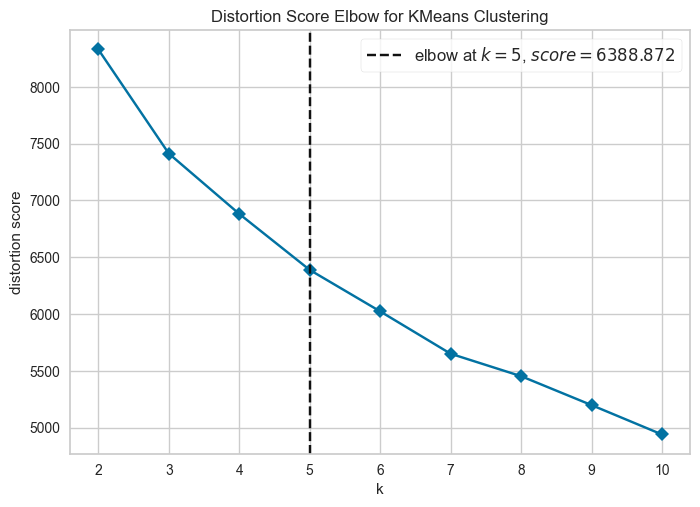


Jumlah cluster optimal: 5


In [43]:
# Elbow Method menggunakan KElbowVisualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=False, force_model=True)
visualizer.fit(df_scaled.values)
visualizer.show()
plt.show()

optimal_k = visualizer.elbow_value_
if optimal_k is None:
    optimal_k = 4
print(f"\nJumlah cluster optimal: {optimal_k}")

In [44]:
# K-Means Clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled.values)

df['Cluster'] = clusters
df_scaled['Cluster'] = clusters

print("Distribusi Cluster:")
print(df['Cluster'].value_counts().sort_index())

Distribusi Cluster:
Cluster
0    332
1    177
2    319
3    345
4    328
Name: count, dtype: int64


In [45]:
# Simpan model clustering
joblib.dump(kmeans, 'model_clustering')
print("✅ Model disimpan: model_clustering")

✅ Model disimpan: model_clustering


### Penilaian
#### Silhouette Score & Visualisasi Cluster

**Metode:** Silhouette Score untuk evaluasi kualitas cluster, dan visualisasi 2D.
**Alasan:** Silhouette Score mengukur seberapa baik data terkelompok.

Silhouette Score: 0.1588


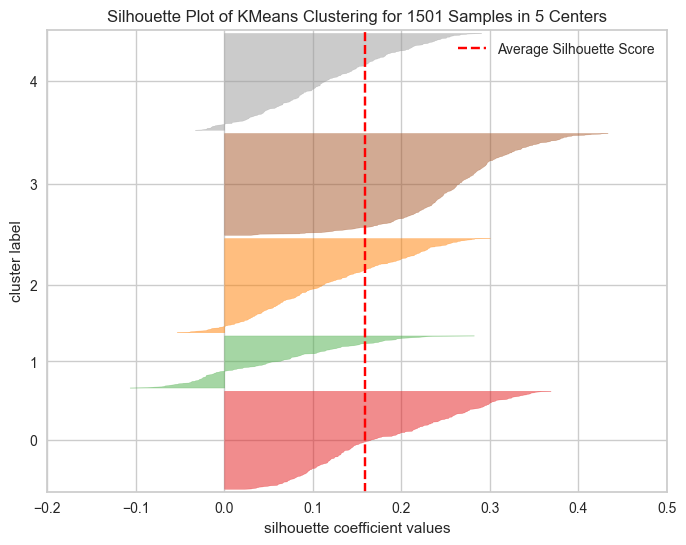

In [46]:
# Silhouette Score
sil_score = silhouette_score(df_scaled.drop(columns=['Cluster']), clusters)
print(f"Silhouette Score: {sil_score:.4f}")

# Visualisasi Silhouette
fig, ax = plt.subplots(figsize=(8, 6))
sv = SilhouetteVisualizer(KMeans(n_clusters=optimal_k, random_state=42, n_init=10), ax=ax, force_model=True)
sv.fit(df_scaled.drop(columns=['Cluster']).values)
sv.show()
plt.show()

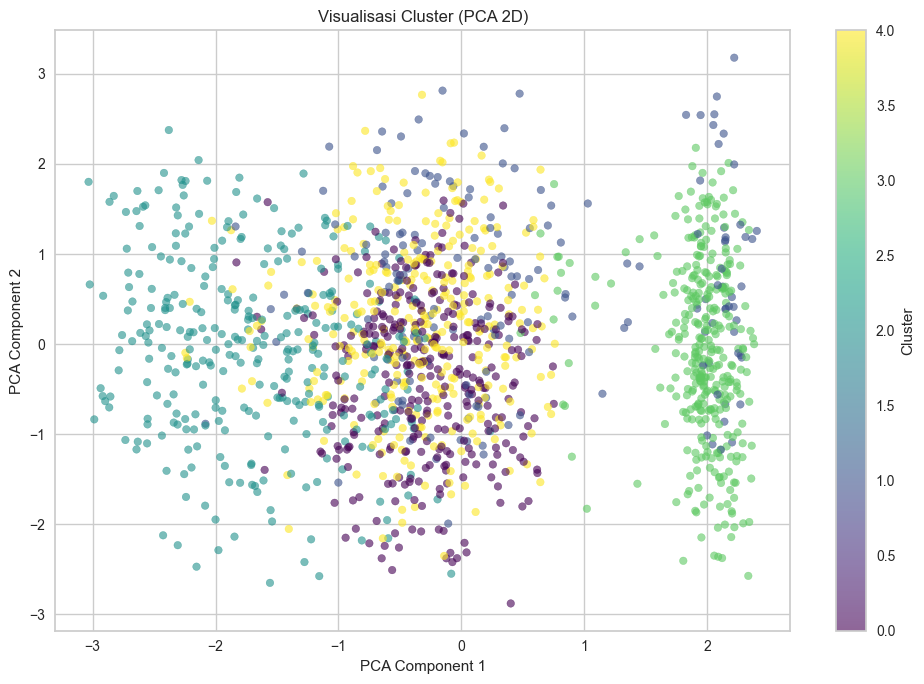

In [47]:
# Visualisasi Cluster 2D
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2, random_state=42)
pca_result = pca_viz.fit_transform(df_scaled.drop(columns=['Cluster']))

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Visualisasi Cluster (PCA 2D)')
plt.tight_layout()
plt.show()

### Penilaian (Opsional)
#### Model PCA Clustering

**Metode:** PCA untuk reduksi dimensi sebelum clustering.
**Alasan:** Mengurangi noise dan mempercepat proses clustering.

In [48]:
# PCA Model Clustering
pca = PCA(n_components=0.95, random_state=42)
df_pca = pca.fit_transform(df_scaled.drop(columns=['Cluster']))
print(f"Komponen PCA: {pca.n_components_}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(df_pca)

sil_pca = silhouette_score(df_pca, clusters_pca)
print(f"Silhouette Score (PCA): {sil_pca:.4f}")
print(f"Silhouette Score (Original): {sil_score:.4f}")

# Simpan PCA model
joblib.dump(kmeans_pca, 'PCA_model_clustering.h5')
print("\n✅ Model PCA disimpan: PCA_model_clustering.h5")

Komponen PCA: 6
Variance explained: 0.9526
Silhouette Score (PCA): 0.1625
Silhouette Score (Original): 0.1588

✅ Model PCA disimpan: PCA_model_clustering.h5


## 5. Interpretasi Cluster
### a. Interpretasi Hasil Clustering

**Metode:** Analisis deskriptif (mean, min, max) dan agregasi per cluster.
**Alasan:** Untuk memahami karakteristik unik setiap cluster.

In [49]:
# Analisis deskriptif mean, min, max
num_cols = [c for c in df.columns if c != 'Cluster']

print("=== Analisis Deskriptif (Mean) ===")
print(df[num_cols].mean().to_frame('Mean'))
print("\n=== Analisis Deskriptif (Min) ===")
print(df[num_cols].min().to_frame('Min'))
print("\n=== Analisis Deskriptif (Max) ===")
print(df[num_cols].max().to_frame('Max'))

=== Analisis Deskriptif (Mean) ===
                            Mean
TransactionAmount     251.879580
TransactionType         1.000000
Location               21.202532
Channel                 0.888741
CustomerAge            44.374417
CustomerOccupation      1.502998
TransactionDuration   119.304464
LoginAttempts           1.000000
AccountBalance       5057.289780

=== Analisis Deskriptif (Min) ===
                        Min
TransactionAmount      0.26
TransactionType        1.00
Location               0.00
Channel                0.00
CustomerAge           18.00
CustomerOccupation     0.00
TransactionDuration   10.00
LoginAttempts          1.00
AccountBalance       102.20

=== Analisis Deskriptif (Max) ===
                          Max
TransactionAmount      903.19
TransactionType          1.00
Location                42.00
Channel                  2.00
CustomerAge             80.00
CustomerOccupation       3.00
TransactionDuration    300.00
LoginAttempts            1.00
AccountBalance 

In [50]:
# Karakteristik tiap cluster - agregasi
print("=== Mean per Cluster ===")
print(df.groupby('Cluster')[num_cols].mean())

print("\n=== Min per Cluster ===")
print(df.groupby('Cluster')[num_cols].min())

print("\n=== Max per Cluster ===")
print(df.groupby('Cluster')[num_cols].max())

=== Mean per Cluster ===
         TransactionAmount  TransactionType   Location   Channel  CustomerAge  \
Cluster                                                                         
0               187.534819              1.0  20.984940  0.265060    59.337349   
1               669.220056              1.0  21.316384  0.920904    41.192090   
2               227.285893              1.0  22.526646  0.617555    48.203762   
3               188.657333              1.0  20.956522  0.942029    23.113043   
4               182.215732              1.0  20.332317  1.710366    49.585366   

         CustomerOccupation  TransactionDuration  LoginAttempts  \
Cluster                                                           
0                  1.590361           116.698795            1.0   
1                  1.751412           128.384181            1.0   
2                  0.178683           128.285266            1.0   
3                  2.988406           120.666667            1.0   
4    

In [51]:
# Interpretasi tiap cluster
overall_mean = df[num_cols].mean()

for cid in sorted(df['Cluster'].unique()):
    cdata = df[df['Cluster'] == cid]
    print(f"\n🔹 Cluster {cid} ({len(cdata)} data, {len(cdata)/len(df)*100:.1f}%):")
    for col in num_cols:
        cm = cdata[col].mean()
        om = overall_mean[col]
        status = "TINGGI" if cm > om else "RENDAH"
        print(f"   {col:25s}: {cm:.4f} ({status} vs rata-rata {om:.4f})")


🔹 Cluster 0 (332 data, 22.1%):
   TransactionAmount        : 187.5348 (RENDAH vs rata-rata 251.8796)
   TransactionType          : 1.0000 (RENDAH vs rata-rata 1.0000)
   Location                 : 20.9849 (RENDAH vs rata-rata 21.2025)
   Channel                  : 0.2651 (RENDAH vs rata-rata 0.8887)
   CustomerAge              : 59.3373 (TINGGI vs rata-rata 44.3744)
   CustomerOccupation       : 1.5904 (TINGGI vs rata-rata 1.5030)
   TransactionDuration      : 116.6988 (RENDAH vs rata-rata 119.3045)
   LoginAttempts            : 1.0000 (RENDAH vs rata-rata 1.0000)
   AccountBalance           : 4325.6275 (RENDAH vs rata-rata 5057.2898)

🔹 Cluster 1 (177 data, 11.8%):
   TransactionAmount        : 669.2201 (TINGGI vs rata-rata 251.8796)
   TransactionType          : 1.0000 (RENDAH vs rata-rata 1.0000)
   Location                 : 21.3164 (TINGGI vs rata-rata 21.2025)
   Channel                  : 0.9209 (TINGGI vs rata-rata 0.8887)
   CustomerAge              : 41.1921 (RENDAH vs rata-

### Penilaian
#### Inverse Transform & Analisis Kategorikal

**Metode:** `inverse_transform()` untuk mengembalikan data ke bentuk asli.
**Alasan:** Agar interpretasi cluster lebih mudah dipahami.

In [52]:
# Inverse Transform - mengembalikan data ke bentuk asli
df_inverse = pd.DataFrame(scaler.inverse_transform(df_scaled.drop(columns=['Cluster'])), columns=df.columns[:-1])

# Inverse Label Encoding
for col, le in label_encoders.items():
    if col in df_inverse.columns:
        df_inverse[col] = df_inverse[col].round().astype(int).clip(0, len(le.classes_)-1)
        df_inverse[col] = le.inverse_transform(df_inverse[col])

# Tambah kolom Target
df_inverse['Target'] = clusters

print("=== Data Setelah Inverse Transform ===")
df_inverse.head()

=== Data Setelah Inverse Transform ===


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,0
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,3
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,3
4,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,3


In [53]:
# Analisis deskriptif setelah inverse - Numerik
num_inv = df_inverse.select_dtypes(include=[np.number]).columns.drop('Target')
cat_inv = df_inverse.select_dtypes(include=['object']).columns

print("=== Numerik: Mean per Cluster ===")
print(df_inverse.groupby('Target')[num_inv].mean())

print("\n=== Numerik: Min per Cluster ===")
print(df_inverse.groupby('Target')[num_inv].min())

print("\n=== Numerik: Max per Cluster ===")
print(df_inverse.groupby('Target')[num_inv].max())

# Analisis deskriptif - Kategorikal
print("\n=== Kategorikal: Mode per Cluster ===")
for col in cat_inv:
    print(f"\n{col}:")
    print(df_inverse.groupby('Target')[col].agg(lambda x: x.value_counts().index[0]))

=== Numerik: Mean per Cluster ===
        TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
Target                                                                       
0              187.534819    59.337349           116.698795            1.0   
1              669.220056    41.192090           128.384181            1.0   
2              227.285893    48.203762           128.285266            1.0   
3              188.657333    23.113043           120.666667            1.0   
4              182.215732    49.585366           106.875000            1.0   

        AccountBalance  
Target                  
0          4325.627470  
1          4006.242655  
2         10397.212727  
3          1459.310116  
4          4956.115366  

=== Numerik: Min per Cluster ===
        TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
Target                                                                       
0                    0.32         26.0                

In [54]:
# Simpan data inverse + Target
df_inverse.to_csv('data_clustering_inverse.csv', index=False)
print(f"✅ Disimpan: data_clustering_inverse.csv ({len(df_inverse)} rows)")

✅ Disimpan: data_clustering_inverse.csv (1501 rows)


## 6. Mengekspor Data

In [55]:
# Ekspor data training + kolom Target
df_export = df.rename(columns={'Cluster': 'Target'})
df_export.to_csv('data_clustering.csv', index=False)

print(f"✅ Disimpan: data_clustering.csv")
print(f"Shape: {df_export.shape}")
print(f"Kolom: {list(df_export.columns)}")
print(f"\nDistribusi Target:")
print(df_export['Target'].value_counts().sort_index())

✅ Disimpan: data_clustering.csv
Shape: (1501, 10)
Kolom: ['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'Target']

Distribusi Target:
Target
0    332
1    177
2    319
3    345
4    328
Name: count, dtype: int64
